# Run a Monte-Carlo Simulation to Estimate the Decoding Error Probability of Short LDPC Codes with a Peeling Decoder

This code is provided as supplementary material of the lecture Channel Coding - Graph-based Codes.

This code illustrates
* Construct a short regular LDPC code
* Run a Monte-Carlo simulation to obtain the block error probability using the simple peeling decoder (equivalent to message passing on the BEC)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ipynb.fs.defs.getRegularH import getRegularH, remove_4cycle

We do not implement a full peeling decoder, but rather a routine that returns the number of residual erasures after peeling decoder. The peeling decoder works as follows: In a loop, it searches for a check node that is connected to one single erased variable node. This variable can then be decoded and its value is determined (it is resolved). It is called "peeling decoder", as we can define a residual graph, which consists of only the erased variable nodes. The non-erased variable nodes are peeled away froim the graph. Then, each check node of degree 1 is found and it is removed together with its connected variable node and each of its edges from the graph. If all nodes are removed, decoding is successful. The performance of the peeling decoder is equivalent to the one     of the BEC message passing decoder, as has been proven in M. Stinner, L. Barletta, P. Olmos, "Finite-length scaling based on belief propagation for spatially coupled LDPC codes", https://arxiv.org/pdf/1604.05111.pdf

In [4]:
def Peeling_Decoder(Hcl, erasures):
    """
    returns residual number of erasures after peeling decoding, erasures is a
    binary (logical) vector indicating at which vns erasures are present
    note that the performance of the peeling decoder is equivalent to the one
    of the BEC message passing decoder, as has been proven in M. Stinner, L.
    Barletta, P. Olmos, "Finite-length scaling based on belief propagation
    for spatially coupled LDPC codes", https://arxiv.org/pdf/1604.05111.pdf
    """
    H = Hcl[:,erasures].copy()
    # find degree-1 checks
    dc1checks = np.sum(H, axis=1) == 1
    assoc_vns = np.asarray(H[dc1checks,:]).nonzero()[1]
    E = H.shape[1]

    while assoc_vns.size > 0:
        H = np.delete(H, assoc_vns, axis=1)
        dc1checks = np.sum(H, axis=1) == 1
        assoc_vns = np.asarray(H[dc1checks,:]).nonzero()[1]
        E = H.shape[1]
    
    return E

Monte-Carlo simulation over 200 different parity-check matrices for each erasure value.

In [5]:
# Remove 4-cycles ?
remove_4cycles = True

# Parameters of the LDPC code
dv = 3
dc = 6
n = 150

# Range of erasure probabilities
eps_range = np.linspace(0.1, 0.43, 15)

# For each epsilon point, denote how many different parity-check matrices we want to simulate (i.e., how many different code realizations). We average over these different code realizations to get a more accurate estimate of the block error rate.
epochs = np.full(len(eps_range), 200, dtype=int)

# Number of frames to simulate for each code realization and epsilon point
frames = 2000

errors = []

epsi = 0

for epsilon in tqdm(eps_range):
    print("epsilon = ", epsilon)
    num_err = 0
    simulated_frames = 0
    for _ in range(int(epochs[epsi])):

        H = getRegularH(n, dv, dc)
        if remove_4cycles:
            H, success = remove_4cycle(H)
            if not success:
                print("Could not remove 4-cycles, skipping this code realization.")
                continue
        
        for _ in range(frames):
            erasures = np.where(np.random.rand(n) < epsilon)[0]
            E = Peeling_Decoder(H, erasures)
            simulated_frames += 1

            if E > 0:
                num_err += 1


    errors.append(num_err / simulated_frames)
    epsi += 1

  0%|          | 0/15 [00:00<?, ?it/s]

epsilon =  0.1
epsilon =  0.12357142857142858
epsilon =  0.14714285714285713
epsilon =  0.1707142857142857
epsilon =  0.19428571428571428
epsilon =  0.21785714285714286
epsilon =  0.2414285714285714
epsilon =  0.265
epsilon =  0.2885714285714286
epsilon =  0.31214285714285717
epsilon =  0.33571428571428574
epsilon =  0.3592857142857143
epsilon =  0.3828571428571428
epsilon =  0.40642857142857136
epsilon =  0.43


Plot the results

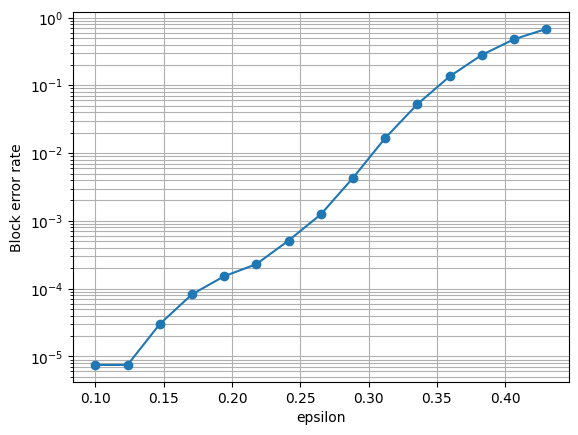

In [6]:
plt.figure()
plt.semilogy(eps_range, errors, marker='o')
plt.xlabel("epsilon")
plt.ylabel("Block error rate")
plt.grid(True, which="both")
plt.show()